# Precedent — first-steps check (Kaggle)

This notebook checks that the core idea works before you build anything else:

1. TabPFN-3.5 installs, downloads its weights and runs on the GPU.
2. A baseline comparison (LightGBM vs TabPFN-3.5) on one enterprise task.
3. Row influence for **one** prediction (random context subsets + ridge regression).
4. The removal test: delete the top precedent rows, re-predict, compare with deleting random rows.

**Before you run (one-time setup)**

- **Settings → Accelerator:** GPU T4. **Settings → Internet:** On.
- **Add-ons → Secrets:** add `TABPFN_TOKEN` (your Prior Labs API key) and `HF_TOKEN` (a Hugging Face read token). Attach both to this notebook.
- On the Prior Labs site, accept the **TabPFN-3.5 licence** under Licenses, with the same account as the API key.
- On Hugging Face, request access to the gated dataset `SAP/SALT`. If access is not granted yet, the notebook falls back to the public *Adult* dataset so you can still check everything else.

In [1]:
!pip install -q -U tabpfn datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 11.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 14.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.9/595.9 kB 14.2 MB/s eta 0:00:0000:01


## 1. Tokens and GPU

In [3]:
import os, time, json, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

def get_secret(name):
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(name)
    except Exception:
        return os.environ.get(name)

TABPFN_TOKEN = get_secret("TABPFN_TOKEN")
HF_TOKEN = get_secret("HF_TOKEN")
assert TABPFN_TOKEN, "Add TABPFN_TOKEN under Add-ons → Secrets and attach it to this notebook."
os.environ["TABPFN_TOKEN"] = TABPFN_TOKEN
os.environ["TABPFN_NO_BROWSER"] = "1"   # Kaggle has no browser for the login flow

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU. Turn on the T4 accelerator, otherwise the ablation loop will be slow.")
print("HF token present:", bool(HF_TOKEN))

GPU available: True
GPU: Tesla T4
HF token present: True


## 2. Smoke test

Downloads the weights and runs one small prediction with both checkpoints.
If this cell fails with a licence or authentication error, accept the TabPFN-3.5 licence on the Prior Labs site and re-run.

In [5]:
import tabpfn
from tabpfn import TabPFNClassifier
from tabpfn.constants import ModelVersion
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
print("tabpfn version:", tabpfn.__version__)

def make_model(fast=True, **overrides):
    version = ModelVersion.V3_5_FAST if fast else ModelVersion.V3_5
    return TabPFNClassifier.create_default_for_version(version, **overrides)

Xs, ys = load_breast_cancer(return_X_y=True)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.5, random_state=42)
smoke = {}
for name, fast in [("TabPFN-3.5-Fast", True), ("TabPFN-3.5", False)]:
    t0 = time.time()
    m = make_model(fast=fast).fit(Xs_tr, ys_tr)
    acc = m.score(Xs_te, ys_te)
    smoke[name] = {"accuracy": round(float(acc), 4), "seconds": round(time.time() - t0, 2)}
    print(name, smoke[name])

tabpfn version: 9.1.0


tabpfn-v3.5-fast-20260909.safetensors: reconstructing file:   0%|          |  0.00B /  334MB            

tabpfn-v3.5-fast-20260909.safetensors: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/36.0 [00:00<?, ?B/s]

TabPFN-3.5-Fast {'accuracy': 0.9754, 'seconds': 9.02}


tabpfn-v3.5-20260909.safetensors: reconstructing file:   0%|          |  0.00B /  876MB            

tabpfn-v3.5-20260909.safetensors: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/36.0 [00:00<?, ?B/s]

TabPFN-3.5 {'accuracy': 0.9789, 'seconds': 4.38}


## 3. Load the data

Tries SAP's SALT (gated, CC-BY-NC-SA 4.0, non-commercial). Falls back to *Adult* if access is missing.
The SALT column names below are my best reading of the dataset card; the cell prints the real columns so you can correct `TARGET_CANDIDATES` if needed.

In [6]:
SALT_TARGETS = ["SALESOFFICE", "SALESGROUP", "CUSTOMERPAYMENTTERMS", "SHIPPINGCONDITION",
                "PLANT", "SHIPPINGPOINT", "HEADERINCOTERMSCLASSIFICATION", "ITEMINCOTERMSCLASSIFICATION"]
TARGET_CANDIDATES = ["CUSTOMERPAYMENTTERMS", "SHIPPINGCONDITION", "PLANT", "SHIPPINGPOINT"]
MAX_ROWS = 200_000      # rows read from SALT; plenty for a first check

def load_salt():
    from datasets import load_dataset, get_dataset_config_names
    cfgs = get_dataset_config_names("SAP/SALT", token=HF_TOKEN)
    print("SALT configs:", cfgs)
    cfg = next((c for c in cfgs if "join" in c.lower()), cfgs[0])
    ds = load_dataset("SAP/SALT", cfg, split="train", token=HF_TOKEN)
    df = ds.select(range(min(MAX_ROWS, len(ds)))).to_pandas()
    upper = {c.upper(): c for c in df.columns}
    target = next((upper[t] for t in TARGET_CANDIDATES if t in upper), None)
    assert target is not None, f"No candidate target found. Columns: {list(df.columns)}"
    leak = [upper[t] for t in SALT_TARGETS if t in upper and upper[t] != target]
    return df.drop(columns=leak), target, f"SALT ({cfg})"

def load_adult():
    from sklearn.datasets import fetch_openml
    df = fetch_openml("adult", version=2, as_frame=True).frame
    return df, "class", "Adult (fallback)"

try:
    df, TARGET, DATA_NAME = load_salt()
except Exception as e:
    print("SALT not available:", type(e).__name__, str(e)[:200])
    df, TARGET, DATA_NAME = load_adult()

print("Dataset:", DATA_NAME, "| shape:", df.shape, "| target:", TARGET)
print("Columns:", list(df.columns))
print(df[TARGET].value_counts(normalize=True).head(10).round(3))

README.md:   0%|          | 0.00/6.70k [00:00<?, ?B/s]

SALT configs: ['default', 'salesdocuments', 'salesdocument_items', 'joined_table', 'customers', 'addresses']


JoinedTables_train.parquet: reconstructing file:   0%|          |  0.00B / 42.8MB            

JoinedTables_train.parquet: downloading bytes:           |  0.00B            

JoinedTables_test.parquet: reconstructing file:   0%|          |  0.00B / 9.19MB            

JoinedTables_test.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1916685 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/402855 [00:00<?, ? examples/s]

Dataset: SALT (joined_table) | shape: (200000, 22) | target: CUSTOMERPAYMENTTERMS
Columns: ['SALESDOCUMENT', 'CUSTOMERPAYMENTTERMS', 'SALESDOCUMENTTYPE', 'SALESORGANIZATION', 'DISTRIBUTIONCHANNEL', 'ORGANIZATIONDIVISION', 'BILLINGCOMPANYCODE', 'TRANSACTIONCURRENCY', 'CREATIONDATE', 'CREATIONTIME', 'SALESDOCUMENTITEM', 'SALESDOCUMENTITEMCATEGORY', 'PRODUCT', 'SOLDTOPARTY', 'SHIPTOPARTY', 'BILLTOPARTY', 'PAYERPARTY', 'ADDRESSID_SOLDTOPARTY', 'ADDRESSID_BILLTOPARTY', 'ADDRESSID_PAYERPARTY', 'ADDRESSID_SHIPTOPARTY', '__index_level_0__']
CUSTOMERPAYMENTTERMS
32    0.246
03    0.178
54    0.096
33    0.084
00    0.043
      0.040
95    0.027
01    0.026
96    0.023
42    0.017
Name: proportion, dtype: float64


## 4. Build the task

- Keeps the 10 most common classes of the target.
- Drops ID-like columns (almost every value unique) and constant columns.
- Uses a time-based split if a date column exists, otherwise a random split.
- 2,000 context rows, 200 test rows.

In [7]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

N_CONTEXT, N_TEST, SEED = 2000, 200, 0
rng = np.random.default_rng(SEED)

d = df.dropna(subset=[TARGET]).copy()
d[TARGET] = d[TARGET].astype(str)
top = d[TARGET].value_counts().index[:10]
d = d[d[TARGET].isin(top)]

date_col = next((c for c in d.columns if "DATE" in c.upper() and c != TARGET), None)
if date_col is not None:
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.sort_values(date_col)
    cut = int(len(d) * 0.8)
    past, future = d.iloc[:cut], d.iloc[cut:]
    print("Time-based split on", date_col)
else:
    d = d.sample(frac=1.0, random_state=SEED)
    cut = int(len(d) * 0.8)
    past, future = d.iloc[:cut], d.iloc[cut:]
    print("Random split (no date column found)")

ctx = past.sample(n=min(N_CONTEXT, len(past)), random_state=SEED)
tst = future[future[TARGET].isin(ctx[TARGET].unique())]
tst = tst.sample(n=min(N_TEST, len(tst)), random_state=SEED)

def is_text(col):
    t = col.dtype
    return (pd.api.types.is_object_dtype(t) or pd.api.types.is_string_dtype(t)
            or isinstance(t, pd.CategoricalDtype))

feat = [c for c in d.columns if c != TARGET]
dropped = []
for c in list(feat):
    nun = ctx[c].nunique(dropna=True)
    if nun <= 1 or (is_text(ctx[c]) and nun > 0.95 * len(ctx)):
        feat.remove(c); dropped.append(c)
print("Dropped columns:", dropped)

def prep(frame):
    out = frame[feat].copy()
    for c in out.columns:
        if pd.api.types.is_datetime64_any_dtype(out[c]):
            out[c] = (out[c] - pd.Timestamp("1970-01-01")).dt.days   # days since 1970
        elif is_text(out[c]):
            out[c] = out[c].astype(object).where(out[c].notna(), "missing").astype(str).astype(object)
    return out.reset_index(drop=True)

X_ctx, X_tst = prep(ctx), prep(tst)
y_ctx, y_tst = ctx[TARGET].to_numpy(), tst[TARGET].to_numpy()

# Numeric copy, used only for LightGBM and for finding nearest rows
cat_cols = [c for c in feat if is_text(X_ctx[c])]
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
E_ctx, E_tst = X_ctx.copy(), X_tst.copy()
if cat_cols:
    E_ctx[cat_cols] = enc.fit_transform(X_ctx[cat_cols])
    E_tst[cat_cols] = enc.transform(X_tst[cat_cols])
E_ctx = E_ctx.astype(float).fillna(-1); E_tst = E_tst.astype(float).fillna(-1)

print("Context:", X_ctx.shape, "| Test:", X_tst.shape, "| Classes:", len(np.unique(y_ctx)))

Time-based split on CREATIONDATE
Dropped columns: ['ORGANIZATIONDIVISION']
Context: (2000, 20) | Test: (200, 20) | Classes: 10


## 5. Baseline: LightGBM vs TabPFN-3.5

In [8]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

def fit_baseline():
    return LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=SEED).fit(E_ctx, y_ctx)

t0 = time.time(); lgbm = fit_baseline()
acc_lgbm = accuracy_score(y_tst, lgbm.predict(E_tst)); t_lgbm = time.time() - t0

t0 = time.time(); full_model = make_model(fast=True).fit(X_ctx, y_ctx)
proba_full = full_model.predict_proba(X_tst); t_tab = time.time() - t0
pred_full = full_model.classes_[proba_full.argmax(1)]
acc_tab = accuracy_score(y_tst, pred_full)

baseline = {"lightgbm_acc": round(float(acc_lgbm), 4), "tabpfn35_fast_acc": round(float(acc_tab), 4),
            "lightgbm_s": round(t_lgbm, 1), "tabpfn_s": round(t_tab, 1)}
print(baseline)

{'lightgbm_acc': 0.505, 'tabpfn35_fast_acc': 0.655, 'lightgbm_s': 3.8, 'tabpfn_s': 0.9}


## 6. Row influence for one prediction

Steps:

1. Pick one test row. A row the model is fairly but not totally sure about is best, because a 100% confident prediction will not move whatever you remove.
2. Take its `K` nearest context rows as the local context.
3. Draw `M` random half-subsets of that local context and re-predict with each.
4. Fit a ridge regression of the predicted probability on row membership. The largest positive coefficients are the **precedents**.

`K = 100` and `M = 300` keep the regression well-posed (more subsets than rows).

In [9]:
from sklearn.linear_model import Ridge
from sklearn.neighbors import NearestNeighbors

K, M, TOP_K, N_EST = 100, 300, 10, 2

# 1. choose the row to explain
conf = proba_full.max(1)
i = int(np.argmin(np.abs(conf - 0.75)))
target_class = pred_full[i]
x_row = X_tst.iloc[[i]]
print(f"Explaining test row {i}: predicted '{target_class}' with p={conf[i]:.3f} (true label '{y_tst[i]}')")

# 2. local context
scaler = StandardScaler().fit(E_ctx)
nn = NearestNeighbors(n_neighbors=min(K, len(E_ctx))).fit(scaler.transform(E_ctx))
local_idx = nn.kneighbors(scaler.transform(E_tst.iloc[[i]]), return_distance=False)[0]
K = len(local_idx)

def p_target(rows):
    # Probability of target_class for the explained row, using only these context rows
    ys_ = y_ctx[rows]
    classes = np.unique(ys_)
    if len(classes) == 1:
        return float(classes[0] == target_class)
    m = make_model(fast=True, n_estimators=N_EST).fit(X_ctx.iloc[rows], ys_)
    p = m.predict_proba(x_row)[0]
    hit = np.where(m.classes_ == target_class)[0]
    return float(p[hit[0]]) if len(hit) else 0.0

p_local = p_target(local_idx)
print(f"p(target) with all {len(X_ctx)} context rows: {conf[i]:.3f} | with the {K} nearest rows only: {p_local:.3f}")

# 3. random half-subsets
def sample_masks(n):
    masks = np.zeros((n, K), dtype=bool)
    for r in range(n):
        masks[r, rng.choice(K, size=K // 2, replace=False)] = True
    return masks

masks = sample_masks(M)
t0 = time.time(); outs = np.zeros(M)
for r in range(M):
    outs[r] = p_target(local_idx[masks[r]])
    if r == 4:
        per = (time.time() - t0) / 5
        print(f"~{per:.2f}s per pass, about {per * M / 60:.1f} min for {M} passes")
t_influence = time.time() - t0

# 4. linear surrogate
surrogate = Ridge(alpha=1.0).fit(masks.astype(float), outs)
coef = surrogate.coef_
order = np.argsort(-coef)
precedents = local_idx[order[:TOP_K]]

show = X_ctx.iloc[precedents].copy()
show.insert(0, "influence", coef[order[:TOP_K]].round(4))
show.insert(1, "label", y_ctx[precedents])
print("Spread of outputs across subsets: std =", outs.std().round(4))
show

Explaining test row 27: predicted '03' with p=0.820 (true label '03')
p(target) with all 2000 context rows: 0.820 | with the 100 nearest rows only: 0.825
~0.53s per pass, about 2.7 min for 300 passes
Spread of outputs across subsets: std = 0.3189


,influence,label,SALESDOCUMENT,SALESDOCUMENTTYPE,SALESORGANIZATION,DISTRIBUTIONCHANNEL,BILLINGCOMPANYCODE,TRANSACTIONCURRENCY,CREATIONDATE,CREATIONTIME,...,PRODUCT,SOLDTOPARTY,SHIPTOPARTY,BILLTOPARTY,PAYERPARTY,ADDRESSID_SOLDTOPARTY,ADDRESSID_BILLTOPARTY,ADDRESSID_PAYERPARTY,ADDRESSID_SHIPTOPARTY,__index_level_0__
488,0.3532,03,0002007980,ZMUN,0010,10,D011,EUR,17578,11:20:02,...,1598676124,2456768605,2456768605,2456768605,2456768605,3000427501,3000427501,3000427501,3000427501,97282
1290,0.3422,03,0002013291,ZMUN,0010,10,D011,EUR,17589,13:08:32,...,1925370928,2456768605,2456768605,2456768605,2456768605,3000427501,3000427501,3000427501,3000427501,120066
951,0.0606,03,0001997979,ZMUN,1600,10,NL80,EUR,17560,15:57:11,...,2180894539,2863823994,2863823994,2863823994,2863823994,3000431794,3000431794,3000431794,3000431794,55386
1694,0.0501,96,0002010962,ZMUN,0010,10,D011,EUR,17584,10:04:48,...,0422017490,1918689129,2199069645,4832963765,4832963765,3000208590,3000474728,3000474728,3000342603,110529
1791,0.0419,32,0002018633,ZMUN,0010,10,D011,EUR,17599,08:38:13,...,0767354232,0851548071,0851548071,0851548071,0851548071,3000208064,3000208064,3000208064,3000208064,142477
831,0.0378,03,0002014443,ZMUN,0010,10,D011,EUR,17591,09:00:14,...,3838520500,0924447914,0924447914,0924447914,0924447914,3000207669,3000207669,3000207669,3000207669,124957
1226,0.0363,96,0001999606,ZMUN,0010,10,D011,EUR,17563,08:36:05,...,3755243785,0170140647,0170140647,4832963765,4832963765,3000208507,3000474728,3000474728,3000208507,61805
248,0.0340,33,0002021417,ZMUN,0700,10,PL10,EUR,17604,15:20:27,...,1842308459,3711491883,3711491883,3711491883,3711491883,3000222653,3000222653,3000222653,3000222653,154580
989,0.0335,32,0002005741,ZMUN,0010,10,D011,EUR,17575,11:47:24,...,1598676124,2287898842,2287898842,3792842533,3792842533,3000519463,3000222656,3000222656,3000519463,87193
1053,0.0333,32,0002009522,ZMUN,0010,10,D011,EUR,17582,12:13:17,...,0357430249,2996171368,2996171368,0603191591,0603191591,3000287477,3000219123,3000219123,3000287477,104148


## 7. Removal test and surrogate check

- **Removal test:** delete the top-10 precedents and re-predict. Compare the drop with deleting 10 random rows (20 repeats).
- **Surrogate check (LDS-style):** on 50 fresh subsets the surrogate has never seen, does it rank the outputs in the right order? Reported as a Spearman correlation.

In [12]:
from scipy.stats import spearmanr

keep = np.ones(K, dtype=bool); keep[order[:TOP_K]] = False
p_removed = p_target(local_idx[keep])
drop_precedent = p_local - p_removed

drops_random = []
for _ in range(20):
    k2 = np.ones(K, dtype=bool); k2[rng.choice(K, size=TOP_K, replace=False)] = False
    drops_random.append(p_local - p_target(local_idx[k2]))
drops_random = np.array(drops_random)

fresh = sample_masks(50)
actual = np.array([p_target(local_idx[mk]) for mk in fresh])
lds = spearmanr(surrogate.predict(fresh.astype(float)), actual).correlation

beats = float((drop_precedent > drops_random).mean())
print(f"p(target): local context {p_local:.3f} -> after removing top-{TOP_K} precedents {p_removed:.3f}")
print(f"Drop from precedents: {drop_precedent:+.3f} | drop from random rows: mean {drops_random.mean():+.3f}, max {drops_random.max():+.3f}")
print(f"Precedent removal beats {beats:.0%} of random removals | surrogate Spearman on fresh subsets: {lds:.3f}")

p(target): local context 0.825 -> after removing top-10 precedents 0.118
Drop from precedents: +0.707 | drop from random rows: mean -0.020, max +0.090
Precedent removal beats 100% of random removals | surrogate Spearman on fresh subsets: 0.644


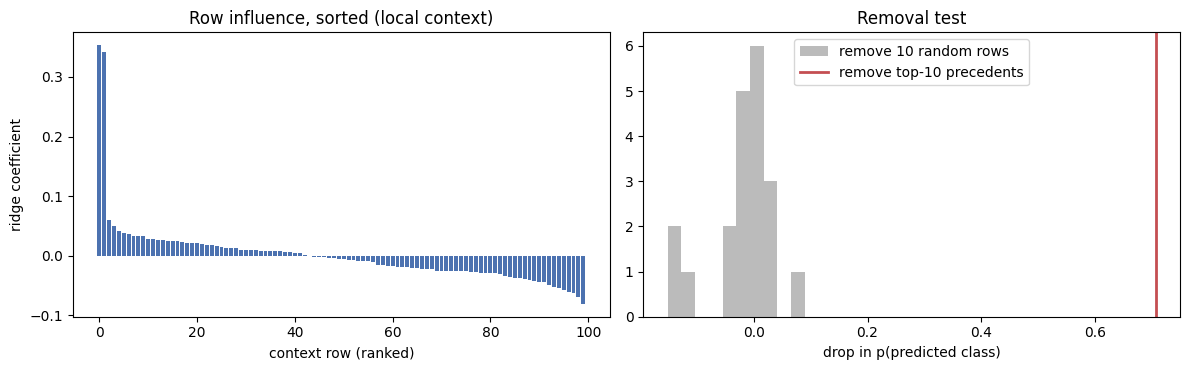

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].bar(range(K), coef[order], color="#4C72B0")
ax[0].set_title("Row influence, sorted (local context)"); ax[0].set_xlabel("context row (ranked)"); ax[0].set_ylabel("ridge coefficient")
ax[1].hist(drops_random, bins=10, color="#BBBBBB", label="remove 10 random rows")
ax[1].axvline(drop_precedent, color="#C44E52", lw=2, label="remove top-10 precedents")
ax[1].set_title("Removal test"); ax[1].set_xlabel("drop in p(predicted class)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 8. Summary

Copy the printed block back into the chat. What to look for:

- **Removal test:** the precedent drop should be clearly larger than the random drops.
- **Surrogate Spearman:** above about 0.5 means the linear surrogate tracks real re-predictions; near 0 means the influence scores are noise.
- **Local vs full prediction:** a big gap means the 100-row local context is not a fair stand-in for the full model.

This is one test row, so treat it as a check that the pipeline runs, not as a result.

In [14]:
summary = {
    "tabpfn_version": tabpfn.__version__, "gpu": torch.cuda.is_available(),
    "dataset": DATA_NAME, "target": TARGET, "n_context": len(X_ctx), "n_test": len(X_tst),
    "n_features": len(feat), "n_classes": int(len(np.unique(y_ctx))),
    "smoke": smoke, "baseline": baseline,
    "explained_row": {"p_full_context": round(float(conf[i]), 4), "p_local_context": round(p_local, 4)},
    "influence": {"K": int(K), "M": int(M), "minutes": round(t_influence / 60, 2), "output_std": round(float(outs.std()), 4)},
    "removal_test": {"drop_precedents": round(float(drop_precedent), 4),
                     "drop_random_mean": round(float(drops_random.mean()), 4),
                     "beats_random_share": beats},
    "surrogate_spearman_fresh": round(float(lds), 3),
}
with open("precedent_first_check.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "tabpfn_version": "9.1.0",
  "gpu": true,
  "dataset": "SALT (joined_table)",
  "target": "CUSTOMERPAYMENTTERMS",
  "n_context": 2000,
  "n_test": 200,
  "n_features": 20,
  "n_classes": 10,
  "smoke": {
    "TabPFN-3.5-Fast": {
      "accuracy": 0.9754,
      "seconds": 9.02
    },
    "TabPFN-3.5": {
      "accuracy": 0.9789,
      "seconds": 4.38
    }
  },
  "baseline": {
    "lightgbm_acc": 0.505,
    "tabpfn35_fast_acc": 0.655,
    "lightgbm_s": 3.8,
    "tabpfn_s": 0.9
  },
  "explained_row": {
    "p_full_context": 0.8198,
    "p_local_context": 0.8246
  },
  "influence": {
    "K": 100,
    "M": 300,
    "minutes": 2.32,
    "output_std": 0.3189
  },
  "removal_test": {
    "drop_precedents": 0.7067,
    "drop_random_mean": -0.02,
    "beats_random_share": 1.0
  },
  "surrogate_spearman_fresh": 0.644
}
